In [1]:
import os
import sys

import math
import time
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
# from YourDataset import YourDataset  # Import your custom dataset here
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torchinfo import summary
import torchprofile

# from utils.architecture import Unet
# from utils.diffusion import ElucidatedDiffusion

torch.manual_seed(23)
import pickle

DTYPE = torch.float32

scaler = GradScaler()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"

import scipy.stats as stats
from sklearn.decomposition import TruncatedSVD

import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"

import matplotlib.colors as mcolors

from scipy.stats import gaussian_kde
from skimage.metrics import structural_similarity as ssim

Using device: cuda


In [2]:
def compute_power(true, pred, inp):
    BS, nt, nx, ny = true.shape

    true = torch.tensor(true, device=device, dtype=DTYPE)
    pred = torch.tensor(pred, device=device, dtype=DTYPE)
    inp = torch.tensor(inp, device=device, dtype=DTYPE)
    
    # Compute the Fourier transforms and amplitude squared for both true and pred
    fourier_true = torch.fft.fftn(true, dim=(-2, -1))
    fourier_pred = torch.fft.fftn(pred, dim=(-2, -1))
    fourier_inp  = torch.fft.fftn(inp , dim=(-2, -1))

    # Get the squared amplitudes
    amplitudes_true = torch.abs(fourier_true) #** 2
    amplitudes_pred = torch.abs(fourier_pred) #** 2
    amplitudes_inp = torch.abs(fourier_inp) #** 2

    # Create the k-frequency grids
    kfreq_y = torch.fft.fftfreq(ny) * ny
    kfreq_x = torch.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = torch.meshgrid(kfreq_x, kfreq_y, indexing='ij')
    
    # Compute the wavenumber grid
    knrm = torch.sqrt(kfreq2D_x ** 2 + kfreq2D_y ** 2).to(true.device)
    
    # Define the bins for the wavenumber
    kbins = torch.arange(0.5, nx // 2 + 1, 1.0, device=true.device)
    
    # Digitize knrm to bin indices
    knrm_flat = knrm.flatten()
    bin_indices = torch.bucketize(knrm_flat, kbins)

    # Reshape and flatten the amplitudes
    amplitudes_true_flat = amplitudes_true.view(BS, nt, nx * ny)
    amplitudes_pred_flat = amplitudes_pred.view(BS, nt, nx * ny)
    amplitudes_inp_flat  = amplitudes_inp.view(BS, nt, nx * ny)

    # Initialize Abins
    Abins_true = torch.zeros((BS, nt, len(kbins) - 1), device=true.device)
    Abins_pred = torch.zeros((BS, nt, len(kbins) - 1), device=pred.device)
    Abins_inp  = torch.zeros((BS, nt, len(kbins) - 1), device= inp.device)

    # Vectorized binning: sum up the values in each bin
    for bin_idx in range(1, len(kbins)):
        mask = (bin_indices == bin_idx).unsqueeze(0).unsqueeze(0)  # Create a mask for each bin
        Abins_true[:, :, bin_idx - 1] = (amplitudes_true_flat * mask).sum(dim=-1) / mask.sum(dim=-1)
        Abins_pred[:, :, bin_idx - 1] = (amplitudes_pred_flat * mask).sum(dim=-1) / mask.sum(dim=-1)
        Abins_inp[:,  :, bin_idx - 1] = (amplitudes_inp_flat  * mask).sum(dim=-1) / mask.sum(dim=-1)

    # Scale the binned amplitudes
    scaling_factor = torch.pi * (kbins[1:] ** 2 - kbins[:-1] ** 2)
    Abins_true *= scaling_factor
    Abins_pred *= scaling_factor
    Abins_inp  *= scaling_factor

    Abins_true = torch.log(Abins_true)
    Abins_pred = torch.log(Abins_pred)
    Abins_inp = torch.log(Abins_inp)
    

    return Abins_true.detach().cpu().numpy(), Abins_pred.detach().cpu().numpy(), Abins_inp.detach().cpu().numpy()

def field_get_err(true, pred):
    return np.mean( np.mean( (true-pred)**2, axis=(2,3) )/np.mean(true**2, axis=(2,3)) )

def spec_get_err(true, pred):
    return np.mean( np.mean( (true-pred)**2, axis=(1,2)  ) /np.mean(true**2, axis=(1,2) ) )

In [3]:
"""
The experiment that investigates the impact of neural operator accuracy on diffusion model
was conducted by varying Par['n_channels']

Par['n_channels'] = 16  corresponds to UNet with 2M   parameters (small)
Par['n_channels'] = 32  corresponds to UNet with 8M   parameters (big)
Par['n_channels'] = 64  corresponds to UNet with 32M  parameters (vbig)
Par['n_channels'] = 128 corresponds to UNet with 128M parameters (vvbig)

Please see Discussion section in the paper for more details about the experiment
"""

# Please choose the file paths correctly

fname_ls = ["small", "big", "vbig", "vvbig"]
param_ls = [2, 8, 32, 128]
true = np.load("cnn_big/edm_lf1/y_true.npy")

no_ls = []
nodm_ls = []

for i in range(len(param_ls)):
    fname = fname_ls[i]
    print(f"\nfname: {fname}")
    no   = np.load(f"cnn_{fname}/edm_lf1/y_no.npy")
    nodm = np.load(f"cnn_{fname}/edm_lf1/y_pred.npy")
    print(f"no  : {no.shape}")
    print(f"nodm: {nodm.shape}")
    no_ls.append(no)
    nodm_ls.append(nodm)


fname: small
no  : (260, 10, 128, 128)
nodm: (260, 10, 128, 128)

fname: big
no  : (260, 10, 128, 128)
nodm: (260, 10, 128, 128)

fname: vbig
no  : (260, 10, 128, 128)
nodm: (260, 10, 128, 128)

fname: vvbig
no  : (260, 10, 128, 128)
nodm: (260, 10, 128, 128)


In [4]:
no_field_err_ls = []
nodm_field_err_ls = []

no_spec_err_ls  = []
nodm_spec_err_ls  = []

for i in range(len(param_ls)):
    no_field_err   = field_get_err(true, no_ls[i])
    nodm_field_err = field_get_err(true, nodm_ls[i])
    no_field_err_ls.append(no_field_err)
    nodm_field_err_ls.append(nodm_field_err)

    true_spec, nodm_spec, no_spec = compute_power(true, nodm_ls[i], no_ls[i])
    
    no_spec_err   = spec_get_err(true_spec, no_spec)
    nodm_spec_err = spec_get_err(true_spec, nodm_spec)
    no_spec_err_ls.append(no_spec_err)
    nodm_spec_err_ls.append(nodm_spec_err)


[0.013737504, 0.012031844, 0.010447169, 0.009447818]
[0.018415064, 0.015852166, 0.013335526, 0.011623755]


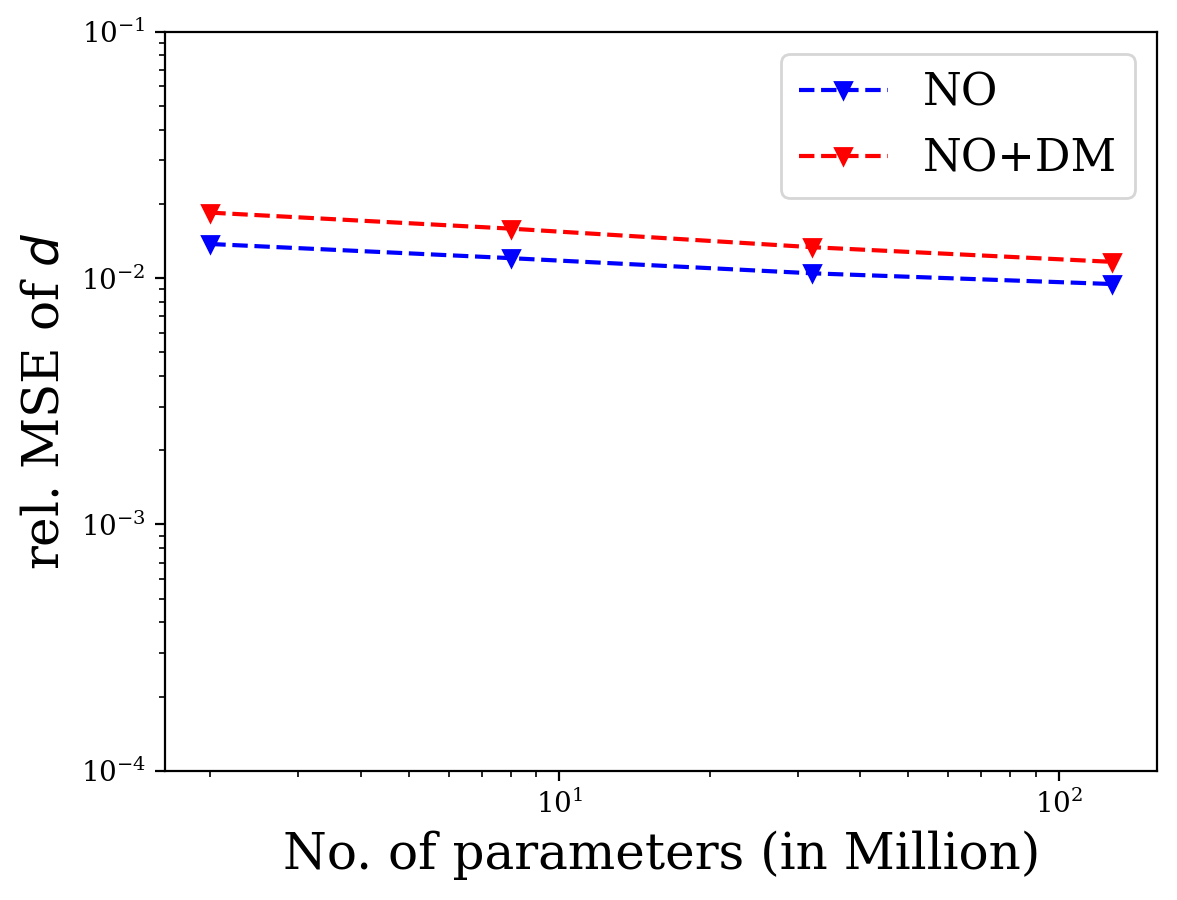

In [5]:
print(no_field_err_ls)
print(nodm_field_err_ls)

plt.plot(param_ls, no_field_err_ls, '--v', color='blue', label=f'NO')
plt.plot(param_ls, nodm_field_err_ls, '--v', color='red', label=f'NO+DM')

plt.xlabel(f"No. of parameters (in Million)", fontsize=18)
plt.ylabel(r"rel. MSE of $d$", fontsize=18)
plt.xscale('log')
plt.yscale('log')
# plt.ylim(0.005,0.05)
plt.ylim(0.0001,0.1)
plt.legend(fontsize=16)
plt.show()

[0.00993831, 0.008100714, 0.0057912306, 0.0037812847]
[0.00069715944, 0.00047063472, 0.00036660742, 0.00031459806]


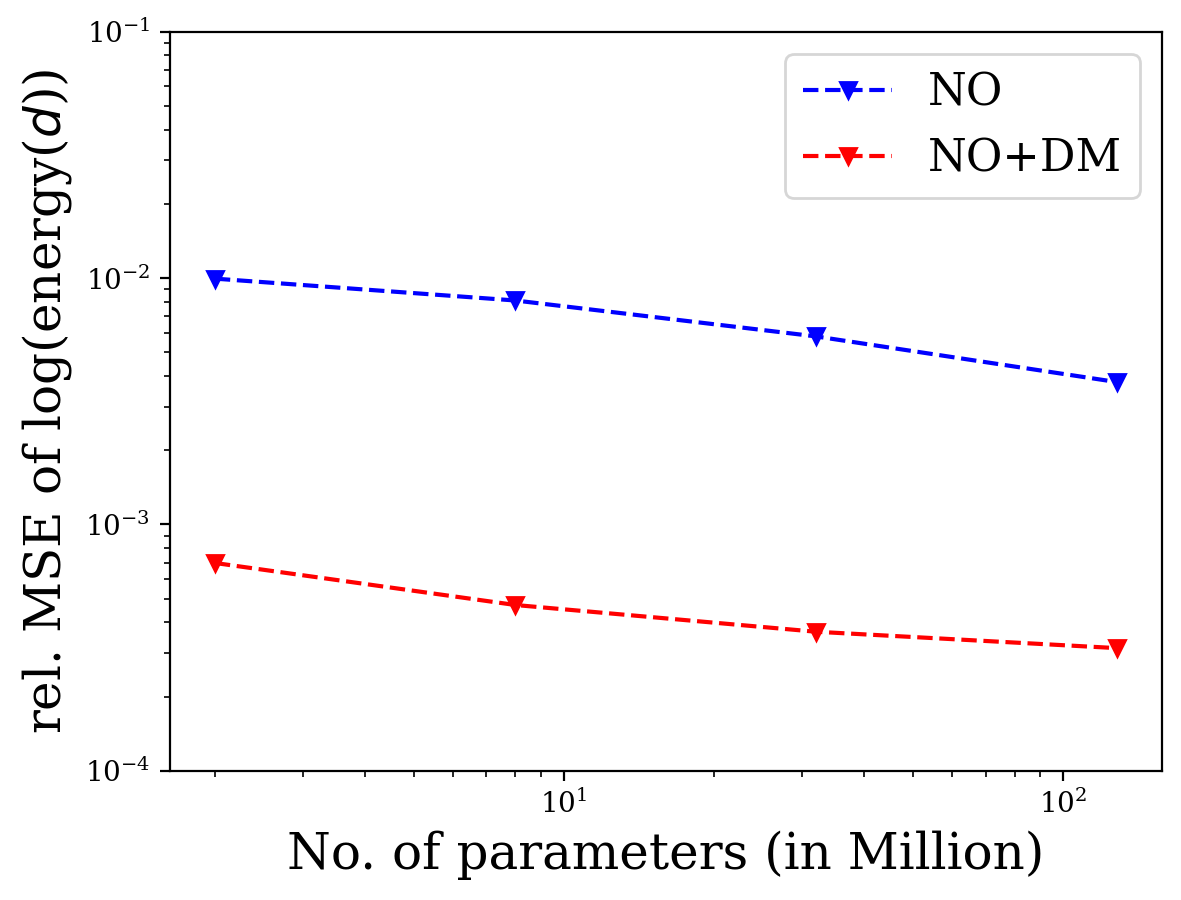

In [12]:
print(no_spec_err_ls)
print(nodm_spec_err_ls)

plt.plot(param_ls, no_spec_err_ls, '--v', color='blue', label=f'NO')
plt.plot(param_ls, nodm_spec_err_ls, '--v', color='red', label=f'NO+DM')

plt.xlabel(f"No. of parameters (in Million)", fontsize=18)
plt.ylabel(r"rel. MSE of log(energy($d$))", fontsize=18)
plt.xscale('log')
plt.yscale('log')
plt.ylim(0.0001,0.1)
plt.legend(fontsize=16)
plt.show()

In [7]:
L = 2*np.pi
N = np.min(true.shape[2:])
delta_x = L/N
k_nq = np.pi/delta_x

def get_power(image):
    npix = image.shape[0]
        
    # Compute the Fourier transform and get the amplitude squared
    fourier_image = np.fft.fftn(image)
    fourier_amplitudes = np.abs(fourier_image)#**2
    
    # Create the k-frequency grid
    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
    # knrm = np.abs(kfreq2D[0]) + np.abs(kfreq2D[1])
    
    # Flatten the arrays to use in binning
    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()
    
    # Define the bins for the wavenumber
    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    kvals = kvals / (0.5*N) * k_nq
    
    # Bin the data
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic="mean",
                                         bins=kbins)
    
    # Scale the binned amplitudes
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2) 

    return kvals, Abins

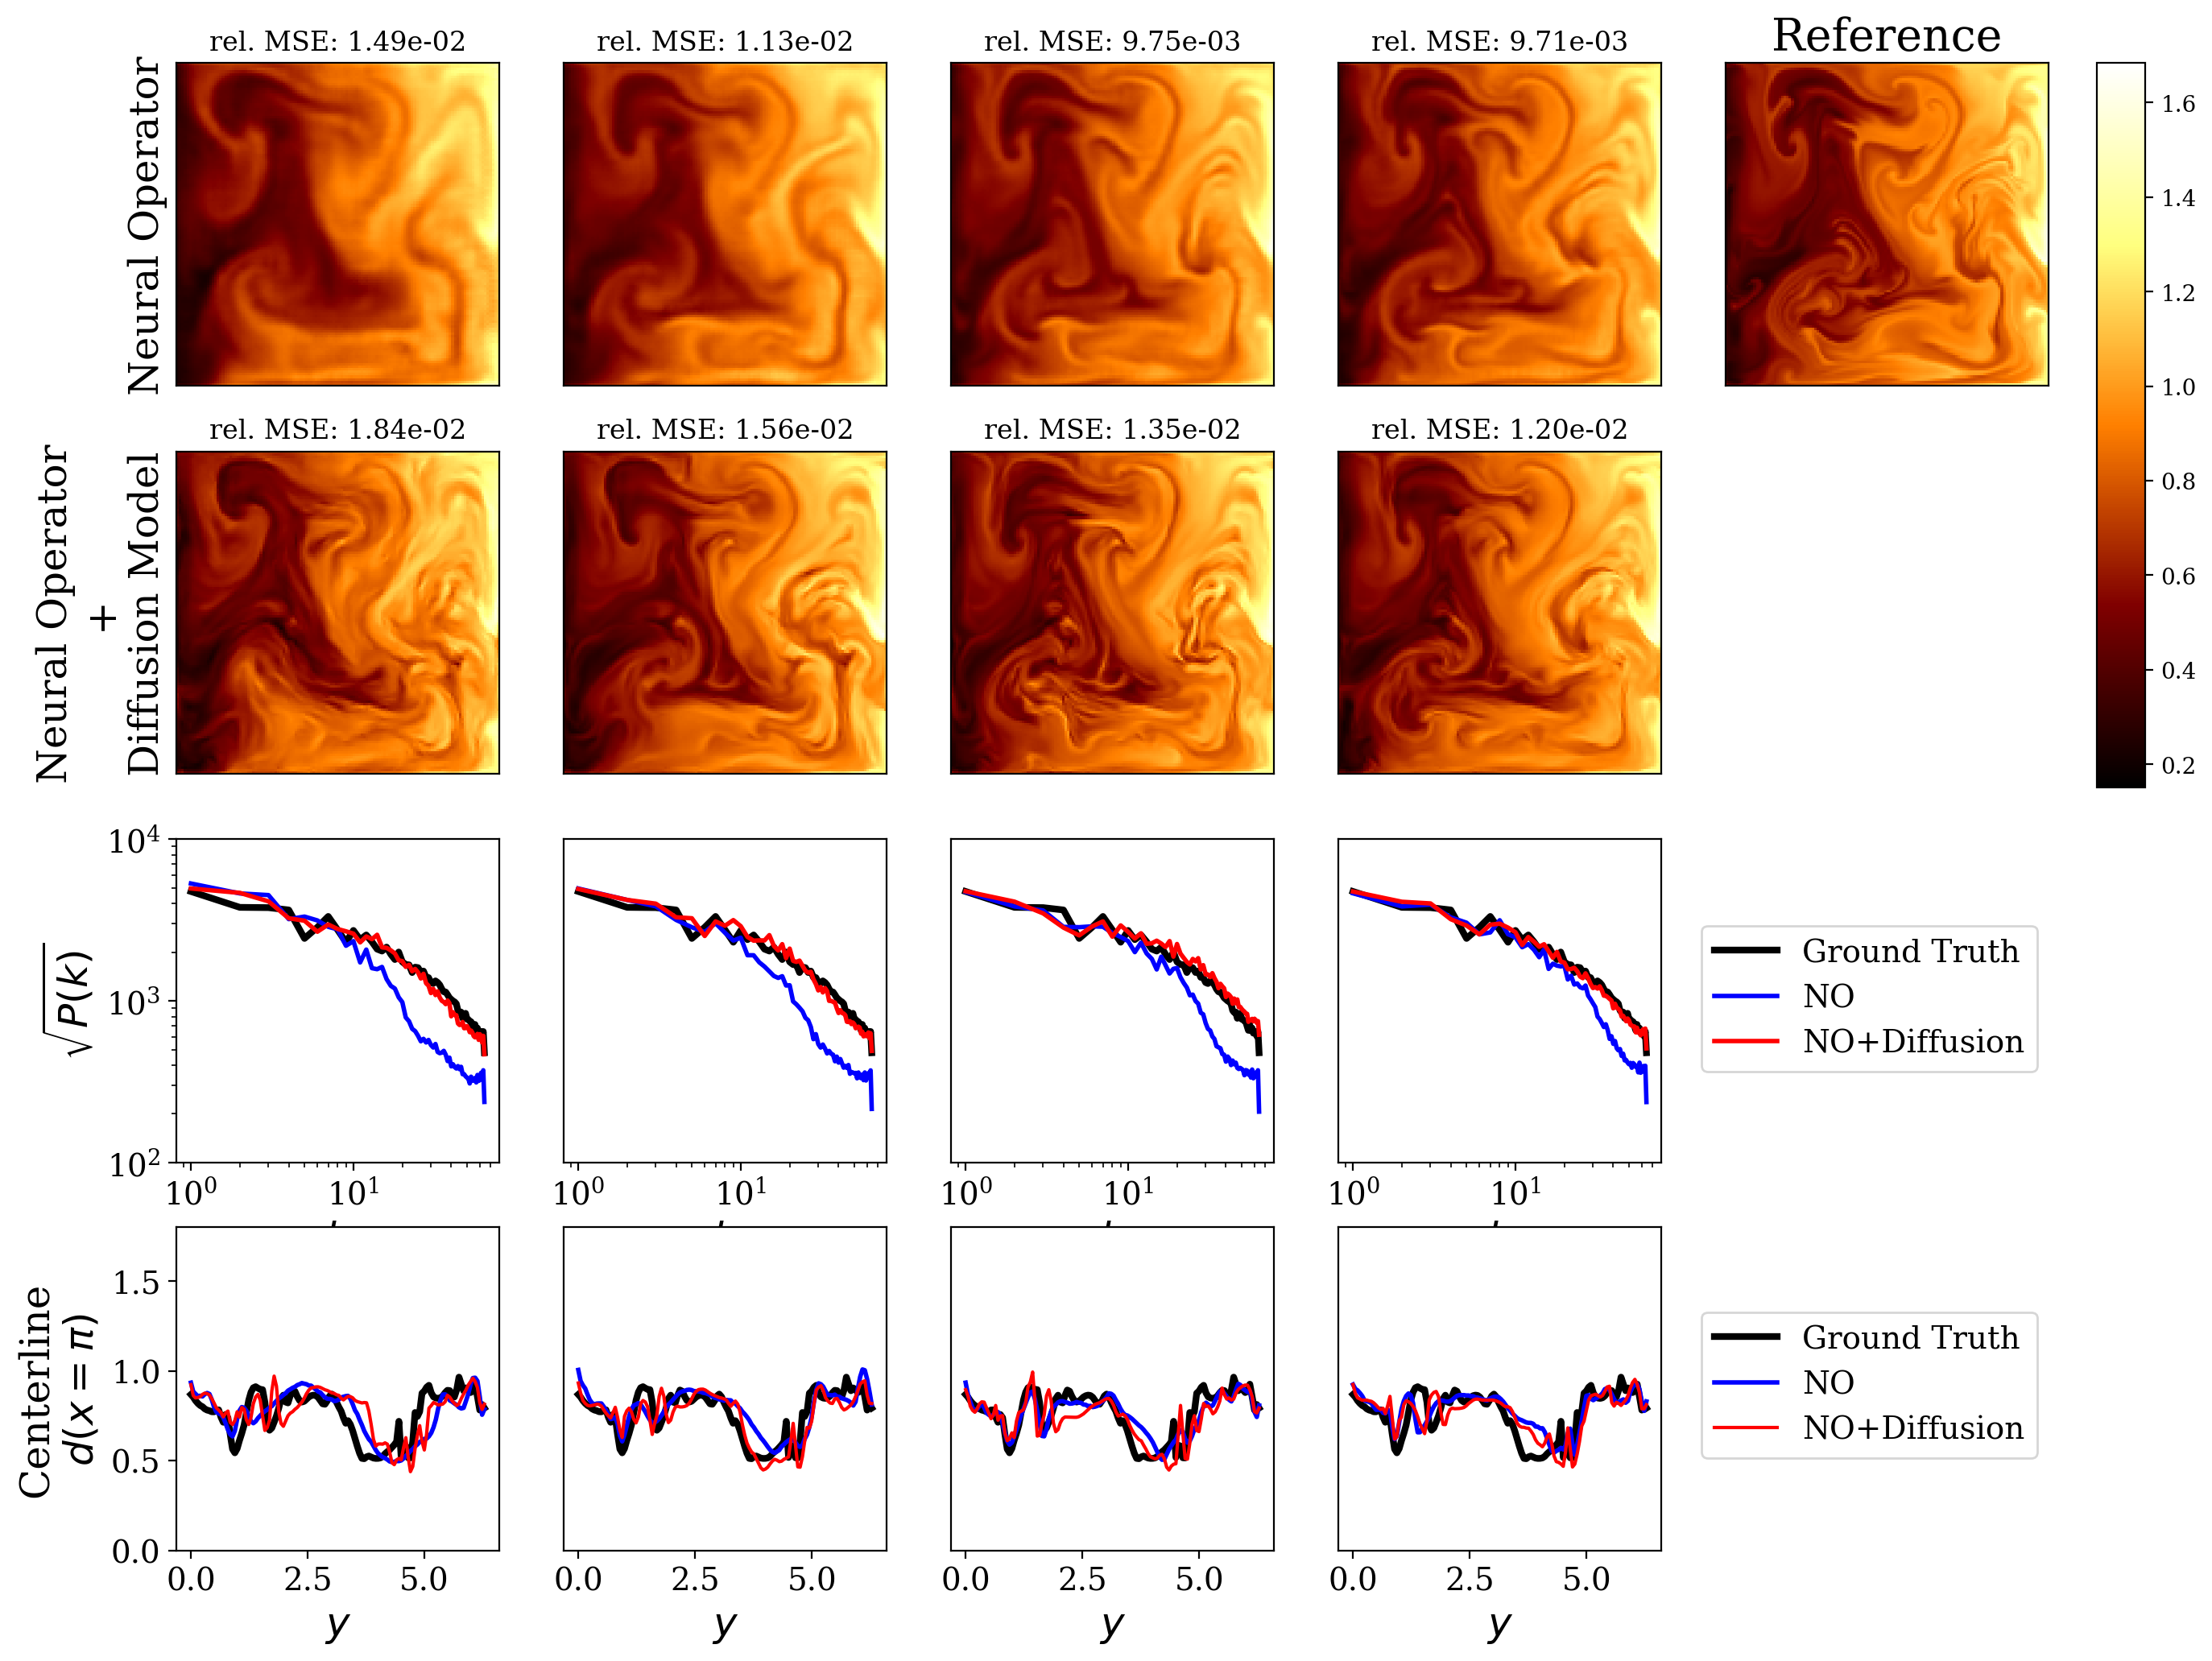

In [8]:
sample_id = 3
t_id = 4

CMAP = 'afmhot'

vmin = true[sample_id].min()
vmax = true[sample_id].max()


f=1.5
fig, axes = plt.subplots(4, 5, figsize=(10*f,8*f))
cbar_ax = fig.add_axes([0.92, 0.505, 0.02, 0.375])  # Colorbar axis

TRUE = true[sample_id, t_id]
for i in range(4):
    
    no   = no_ls[i][sample_id, t_id]
    nodm = nodm_ls[i][sample_id, t_id]
    param = param_ls[i]
    

    p = 0
    axes[p,i].imshow(no, cmap=CMAP, vmin=vmin, vmax=vmax)
    axes[p,i].set_xticks([])
    axes[p,i].set_yticks([])
    err = np.mean( (TRUE - no)**2 )/np.mean(TRUE**2)
    axes[p,i].set_title(f"rel. MSE: {err:.2e}")
    # axes[p,i].set_title(f"{param}M\n<small>rel. MSE: {err:.2e}</small>")
    if i == 0:
        axes[p,i].set_ylabel(f"Neural Operator", fontsize=18)

    p = 1
    axes[p,i].imshow(nodm, cmap=CMAP, vmin=vmin, vmax=vmax)
    axes[p,i].set_xticks([])
    axes[p,i].set_yticks([])
    err = np.mean( (TRUE - nodm)**2 )/np.mean(TRUE**2)
    axes[p,i].set_title(f"rel. MSE: {err:.2e}")
    if i == 0:
        axes[p,i].set_ylabel(f"Neural Operator\n+\nDiffusion Model", fontsize=18)

    p = 2
    kvals, Abins = get_power(TRUE)
    axes[p,i].loglog(kvals, Abins, c='black', label="Ground Truth", linewidth=3)
    kvals, Abins = get_power(no)
    axes[p,i].loglog(kvals, Abins, label="NO", c='blue', linewidth=2)
    kvals, Abins = get_power(nodm)
    axes[p,i].loglog(kvals, Abins, label="NO+Diffusion", c='red', linewidth=2)
    
    axes[p, i].set_ylim(1*10**2,10**4)

    for ax in axes[p, :4]:  # Adjusting only the last row axes
        ax.tick_params(axis='both', which='major', labelsize=14)

    if i==0:
        axes[p,i].set_ylabel(r'$\sqrt{P(k)}$', fontsize=18)
    if i!=0:
        axes[p,i].get_yaxis().set_visible(False)        

    axes[p, i].set_xlabel('$k$', fontsize=18)
    
    if i == 3:
        leg = axes[p, i].legend()
        # axes[3, i1].legend(loc='upper \left', bbox_to_anchor=(1.05, 1), frameon=False)
        handles, labels = axes[p, i].get_legend_handles_labels()

        # Remove the original legend from the axes
        leg.remove()
        
        # Define custom coordinates for the new legend (adjust these values to your liking)
        custom_x = 0.75  # Adjust this value to move left-right
        custom_y = 0.35  # Adjust this value to move up-down
        
        # Create a new standalone legend at the custom coordinates on the figure
        fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(custom_x, custom_y), fontsize=14)

    p = 3
    x = np.linspace(0, 2*np.pi, 128)
    true_line = TRUE[:,64]
    no_line   = no[:,64]
    nodm_line = nodm[:,64]
    axes[p,i].plot(x, true_line, c='black', label="Ground Truth", linewidth=3)
    axes[p,i].plot(x, no_line, label="NO", c='blue', linewidth=2)
    axes[p,i].plot(x, nodm_line, label="NO+Diffusion", c='red', linewidth=1.5)

    axes[p, i].set_ylim(0,1.8)

    for ax in axes[p, :4]:  # Adjusting only the last row axes
        ax.tick_params(axis='both', which='major', labelsize=14)

    if i==0:
        axes[p,i].set_ylabel(f'Centerline\n'+r'$d(x=\pi)$', fontsize=18)
    if i!=0:
        axes[p,i].get_yaxis().set_visible(False)        

    axes[p, i].set_xlabel('$y$', fontsize=18)
    
    if i == 3:
        leg = axes[p, i].legend()
        # axes[3, i1].legend(loc='upper \left', bbox_to_anchor=(1.05, 1), frameon=False)
        handles, labels = axes[p, i].get_legend_handles_labels()

        # Remove the original legend from the axes
        leg.remove()
        
        # Define custom coordinates for the new legend (adjust these values to your liking)
        custom_x = 0.75  # Adjust this value to move left-right
        custom_y = 0.15  # Adjust this value to move up-down
        
        # Create a new standalone legend at the custom coordinates on the figure
        fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(custom_x, custom_y), fontsize=14)

im = axes[0,4].imshow(TRUE, cmap=CMAP, vmin=vmin, vmax=vmax)
axes[0,4].set_xticks([])
axes[0,4].set_yticks([])
axes[0,4].set_title(f"Reference", fontsize=20)
for j in range(1,4):
    axes[j,4].axis("off")

fig.colorbar(im, cax=cbar_ax)

plt.show()